# MURI: Modelling actuator self-assembly

## Import and start Polyscope

First, import statements

In [1]:
import numpy as np
import triangle as tr
import polyscope as ps
import fabsim_py
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

Then, generate the 2D mesh for tissue

In [2]:
vertices = [
[4.116003, 1.403990],
[4.034014, 1.537785],
[4.176056, 1.259017],
[3.678986, 1.841007],
[3.534014, 1.901057],
[3.932104, 1.657107],
[3.812784, 1.759017],
[3.381433, 1.937688],
[3.224997, 1.950000],
[0.000000, 1.950000],
[4.224998, 0.000000],
[4.224998, 0.950000],
[4.212687, 1.106434],
[-4.116003, 1.403990],
[-4.034014, 1.537785],
[-4.176056, 1.259017],
[-3.678986, 1.841007],
[-3.534014, 1.901057],
[-3.932104, 1.657107],
[-3.812784, 1.759017],
[-3.381433, 1.937688],
[-3.224997, 1.950000],
[-4.224998, 0.000000],
[-4.224998, 0.950000],
[-4.212687, 1.106434],
[4.116003, -1.403990],
[4.034014, -1.537785],
[4.176056, -1.259017],
[3.678986, -1.841007],
[3.534014, -1.901057],
[3.932104, -1.657107],
[3.812784, -1.759017],
[3.381433, -1.937688],
[3.224997, -1.950000],
[0.000000, -1.950000],
[4.224998, -0.950000],
[4.212687, -1.106434],
[-4.116003, -1.403990],
[-4.034014, -1.537785],
[-4.176056, -1.259017],
[-3.678986, -1.841007],
[-3.534014, -1.901057],
[-3.932104, -1.657107],
[-3.812784, -1.759017],
[-3.381433, -1.937688],
[-3.224997, -1.950000],
[-4.224998, -0.950000],
[-4.212687, -1.106434]
]
segments = [[11,12],[5,6],[7,8],[3,4],[3,6],[8,9],[0,1],[0,2],[4,7],[1,5],[10,11],[2,12],[23,24],[18,19],[20,21],[16,17],[16,19],[21,9],[13,14],[13,15],[17,20],[14,18],[22,23],[15,24],[35,36],[30,31],[32,33],[28,29],[28,31],[33,34],[25,26],[25,27],[29,32],[26,30],[10,35],[27,36],[46,47],[42,43],[44,45],[40,41],[40,43],[45,34],[37,38],[37,39],[41,44],[38,42],[22,46],[39,47]]
n_boundary = len(vertices)
n_circle = 16
def make_circle(radius, centerX, centerY):
  n = len(vertices)
  for i in range(n_circle):
    vertices.append([centerX + radius * np.cos(2 * i / n_circle * np.pi), centerY + radius * np.sin(2 * i / n_circle * np.pi)])
    segments.append([n + i, n + ((i + 1) % n_circle)])

make_circle(0.75, -4.55 / 2, 0)
make_circle(0.75, 4.55 / 2, 0)
holes = [[-2.25, 0], [2.25, 0]]

A = dict(vertices=vertices, segments=segments, holes=holes)
B = tr.triangulate(A, 'pqa0.1')

zeros = np.zeros((len(B['vertices']), 1))
P = np.hstack((np.array(B['vertices']), zeros))
F = np.array(B['triangles'])

Export mesh

In [3]:
import pyvista as pv
import numpy as np
pv.set_plot_theme('document')

cells = np.hstack((np.full((F.shape[0], 1), 3), F[:])).flatten()
celltypes = np.full(F.shape[0], pv.CellType.TRIANGLE)
points = P
mesh = pv.PolyData(var_inp=points, faces=cells)
pl = pv.Plotter()
_ = pl.add_mesh(mesh)
pl.export_obj('top_surface.obj')  


Show initial mesh

In [4]:
# Initialize polyscope
ps.init()
ps.set_give_focus_on_show(True)
ps.set_ground_plane_mode("shadow_only")

ps_mesh = ps.register_surface_mesh("Initial mesh", P, F, smooth_shade=True, enabled=True)
ps.set_navigation_style("planar")
ps.set_view_projection_mode("orthographic")
ps.set_SSAA_factor(3)
ps.set_view_from_json('{"farClipRatio":20.0,"fov":16.0,"nearClipRatio":0.005,"projectionMode":"Orthographic","viewMat":[1.0,-0.0,0.0,-0.0,0.0,0.997785151004791,-0.0665190145373344,0.000246047973632812,-0.0,0.0665190145373344,0.997785151004791,-25.5602951049805,0.0,0.0,0.0,1.0],"windowHeight":1964,"windowWidth":3456}')
ps.show()

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.1 Metal - 88.1


## Display compaction with polar plots

In [5]:
def polygons(polymer_frac, scale):
  n = polymer_frac.shape[1]
  polygon = []
  rotated_polygon = []
  for i in range(n):
    angle = np.pi / n * i
    polygon.append(np.array([np.cos(angle), np.sin(angle), 0.0]))
    rotated_polygon.append(np.array([np.cos(angle + np.pi), np.sin(angle + np.pi), 0.0]))
  polygon = scale * np.array(polygon)
  rotated_polygon = scale * np.array(rotated_polygon)

  # faces = np.arange(F.shape[0] * 2 * n).reshape(F.shape[0], 2 * n)
  polygon_face = np.zeros((2 * n, 3))
  polygon_face[:, 1] = np.arange(1, 2 * n + 1)
  polygon_face[:, 2] = np.arange(2, 2 * n + 2)
  polygon_face[2 * n - 1, 2] = 1

  verts = []
  faces = []
  for i in range(F.shape[0]):
    center = (V[F[i, 0], :] + V[F[i, 1], :] + V[F[i, 2], :]) / 3
    verts.append(center.reshape((1, 3)))
    verts.append(polygon * polymer_frac[i, :][:, None] + center)
    verts.append(rotated_polygon * polymer_frac[i, :][:, None] + center)
    faces.append(polygon_face + i * (2 * n + 1))
  verts = np.concatenate(verts, axis=0)
  verts[:, 2] = 0.1
  faces = np.concatenate(faces, axis=0)

  return verts, faces


Constants

In [6]:
dt = 1 / 24
k0 = 1e-4
k1 = 5e-2
kd = 0.1 # rate of dissociation
e0 = 1.2e-1
e1 = 1.7e-1
frac_f = 0.7
frac_s = 0.25
n = 16

fixed_dofs = []
for i in range(n_boundary, n_boundary + len(holes) * n_circle):
  fixed_dofs.append(3 * i)
  fixed_dofs.append(3 * i + 1)
  fixed_dofs.append(3 * i + 2)

Iterative compaction in 20 steps

In [7]:
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()

for k in range(9, 10):
  stretch_factor = 1 + 0.5 * (k + 1) / 10.
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
  ps_mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255))
  sigmas = 1.0 * fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
  
  for i in range(1000):
    fabsim_py.polymer_fraction_one_step(polymer_frac, sigmas, k0, k1, kd, frac_f, frac_s, dt)
    fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
    sigmas = 1.0 * fabsim_py.fiber_stress(V, P / stretch_factor, F, n)

  verts, faces = polygons(polymer_frac, 0.5)
  ps.register_surface_mesh("polymer frac", verts, faces, enabled=True, color=(213/255, 202/255, 42/255))
  ps.show()
  # ps.screenshot()

KeyboardInterrupt: 

## Steady-state solution for fiber distribution

In [23]:
stretch_factor = 1.5
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()

for i in range(10):
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
  stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
  polymer_frac = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)
  verts, faces = polygons(polymer_frac, 0.5)
  ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255))
  ps.register_surface_mesh("polymer frac", verts, faces, enabled=True, color=(213/255, 202/255, 42/255))
  ps.show()


Polar plot of result in face #392

## Convergence of solutions

Convergence of ODE

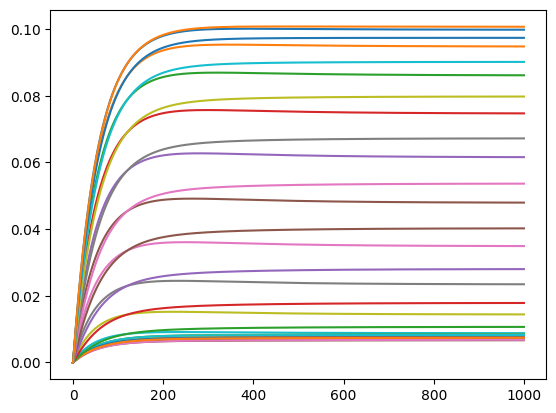

In [24]:
face_id = 392
stretch_factor = 1.5
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()
phi_t = [np.zeros(n)]

for i in range(1000):
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
  sigmas = 1.0 * fabsim_py.fiber_stress(V, P / stretch_factor, F, n)
  fabsim_py.polymer_fraction_one_step(polymer_frac, sigmas, k0, k1, kd, frac_f, frac_s, dt)
  phi_t.append(polymer_frac[face_id, :].copy())

phi_t = np.array(phi_t)

for i in range(n):
  plt.plot(phi_t[:, i])
plt.show()

Convergence of steady-state solution

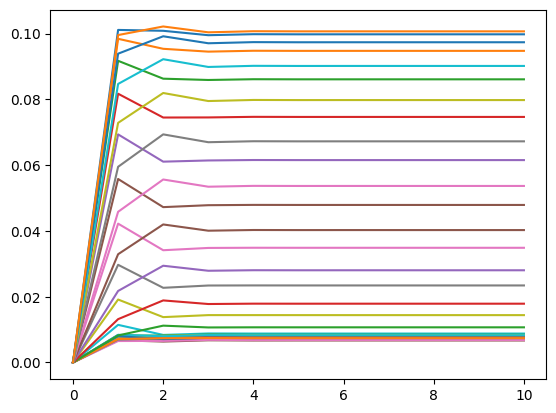

In [25]:
stretch_factor = 1.5
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()
phi_t = [np.zeros(n)]

for i in range(10):
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
  stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
  polymer_frac = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)
  phi_t.append(polymer_frac[face_id, :].copy())

phi_t = np.array(phi_t)

for i in range(n):
  plt.plot(phi_t[:, i])
plt.show()

## Nonlinear least-squares fitting for ODE coefficients

In [26]:
def fitting(phi_measured):
  def fun(params):
    k1 = params[0]
    kd = params[1]
    e0 = params[2]
    e1 = params[3]

    stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
    phi = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

    for i in range(2):
      fabsim_py.simulate_membrane(V, P, F, phi, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
      stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
      phi = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)


    return (phi - phi_measured).flatten()

  initial_guess = np.array([5e-2, 0.1, 1.2e-1, 1.7e-1])
  return least_squares(fun, initial_guess)

Polar plot for "ground truth" solution

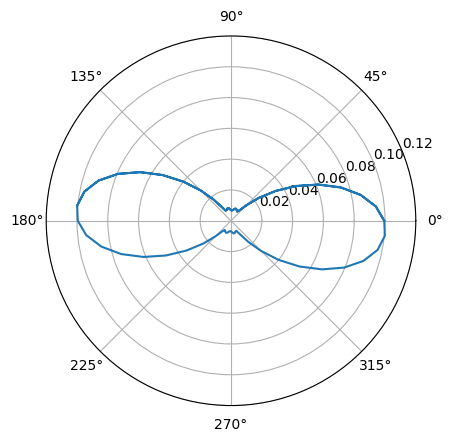

In [47]:
stretch_factor = 1.5
n = 32
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()

import math

for i in range(3):
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
  stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
  polymer_frac = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / n * i for i in range(3 * n)], np.tile(polymer_frac[face_id, :], 3))
ax.set_rmax(0.12)

plt.show()

Polar plot for fake "measured data" (= ground thruth + noise)

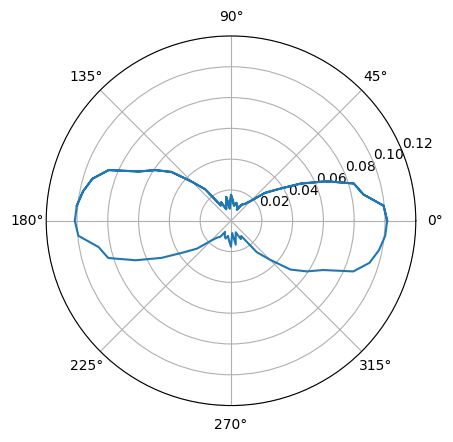

In [48]:
phi_measured = polymer_frac + 0.01 * np.random.default_rng().random(polymer_frac.shape)

_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / n * i for i in range(3 * n)], np.tile(phi_measured[face_id, :], 3))
ax.set_rmax(0.12)

plt.show()

0.05 0.1 0.12 0.17
0.044861433320661774 0.05628900536105358 0.15566867159514977 0.1831647590242478


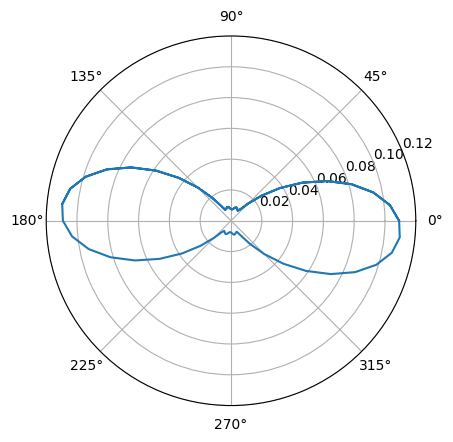

In [49]:
params = fitting(phi_measured)

print(k1, kd, e0, e1)

k1 = params.x[0]
kd = params.x[1]
e0 = params.x[2]
e1 = params.x[3]

print(k1, kd, e0, e1)

phi_recovered = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / n * i for i in range(3 * n)], np.tile(phi_recovered[face_id, :], 3))
ax.set_rmax(0.12)

plt.show()

In [2]:
import pyvista as pv
import tetgen
import numpy as np
pv.set_plot_theme('document')

cylinder = pv.Cylinder(direction=(1,0,0), radius=1, height=10, resolution=25).triangulate()
tet = tetgen.TetGen(cylinder)
V, F = tet.tetrahedralize(order=1, mindihedral=15, minratio=2)
grid = tet.grid
grid.plot(cpos='xz', show_edges=True)

Widget(value='<iframe src="http://localhost:54257/index.html?ui=P_0x11d611dc0_0&reconnect=auto" class="pyvista…

In [4]:
import fabsim_py

fixed_dofs = []
for i in range(V.shape[0]):
  if(V[i, 0] < -5 + 1e-6):
    fixed_dofs.append(3 * i)
    fixed_dofs.append(3 * i + 1)
    fixed_dofs.append(3 * i + 2)

NV = V.copy()
fabsim_py.simulate3D(NV, V, F, fixed_dofs, 1, 0.3, 1e-5)

cells = np.hstack((np.full((F.shape[0], 1), 4), F[:])).flatten()
celltypes = np.full(F.shape[0], pv.CellType.TETRA)
points = NV
grid = pv.UnstructuredGrid(cells, celltypes, points)
grid.plot(cpos='xz', show_edges=True)

Initial energy: -0.130683
Decrement in iteration 0: 0.554248	Factorization = Exact
Decrement in iteration 1: 0.287173	Factorization = Exact
Decrement in iteration 2: 3.26918e-06	Factorization = Exact
Decrement in iteration 3: 1.8026e-11	Factorization = Exact
Final energy: -0.685881


Widget(value='<iframe src="http://localhost:54257/index.html?ui=P_0x169bd2d20_1&reconnect=auto" class="pyvista…

In [7]:
import pyvista as pv
import tetgen
import numpy as np
pv.set_plot_theme('document')

mesh = pv.read("tissue.obj")
print(mesh)
tet = tetgen.TetGen(mesh)
V, F = tet.tetrahedralize(order=1, mindihedral=20, minratio=1.5)
grid = tet.grid
grid.plot(show_edges=True)


PolyData (0x3306c0220)
  N Cells:    1192
  N Points:   3576
  N Strips:   0
  X Bounds:   -4.225e+00, 4.225e+00
  Y Bounds:   -1.950e+00, 1.950e+00
  Z Bounds:   -1.118e+00, 0.000e+00
  N Arrays:   6


Widget(value='<iframe src="http://localhost:54257/index.html?ui=P_0x33181e3c0_3&reconnect=auto" class="pyvista…

In [11]:
fixed_dofs = []

def fix_dofs_in_circle(radius, centerX, centerY):
  center = np.array([centerX, centerY])
  for i in range(V.shape[0]):
    if np.linalg.norm(center - V[i, :2]) < radius + 1e-6:
      fixed_dofs.append(3 * i)
      fixed_dofs.append(3 * i + 1)

fix_dofs_in_circle(0.75, -4.55/2, 0)
fix_dofs_in_circle(0.75, 4.55/2, 0)
print(fixed_dofs)

NV = V.copy()
fabsim_py.simulate3D(NV, V, F, fixed_dofs, 1.3, 0.3, 0)
fabsim_py.simulate3D(NV, V, F, fixed_dofs, 1.4, 0.3, 0)
fabsim_py.simulate3D(NV, V, F, fixed_dofs, 1.5, 0.3, 0)
fabsim_py.simulate3D(NV, V, F, fixed_dofs, 1.6, 0.3, 0)

cells = np.hstack((np.full((F.shape[0], 1), 4), F[:])).flatten()
celltypes = np.full(F.shape[0], pv.CellType.TETRA)
points = NV
grid = pv.UnstructuredGrid(cells, celltypes, points)
grid.plot(show_edges=True)


[63, 64, 105, 106, 237, 238, 243, 244, 261, 262, 279, 280, 345, 346, 384, 385, 396, 397, 414, 415, 828, 829, 834, 835, 942, 943, 981, 982, 987, 988, 1029, 1030, 1077, 1078, 1107, 1108, 1116, 1117, 1479, 1480, 1488, 1489, 1491, 1492, 1509, 1510, 1560, 1561, 1569, 1570, 1605, 1606, 1620, 1621, 1677, 1678, 1680, 1681, 1695, 1696, 1725, 1726, 1734, 1735, 1992, 1993, 1995, 1996, 1998, 1999, 2001, 2002, 2004, 2005, 2007, 2008, 2010, 2011, 2013, 2014, 2016, 2017, 2019, 2020, 2022, 2023, 2025, 2026, 2028, 2029, 2031, 2032, 2034, 2035, 2037, 2038, 2643, 2644, 2721, 2722, 2736, 2737, 2769, 2770, 2868, 2869, 3003, 3004, 3105, 3106, 3147, 3148, 3243, 3244, 3303, 3304, 3342, 3343, 3513, 3514, 3537, 3538, 3621, 3622, 3645, 3646, 3750, 3751, 3810, 3811, 3843, 3844, 3906, 3907, 12, 13, 141, 142, 150, 151, 156, 157, 189, 190, 231, 232, 258, 259, 849, 850, 852, 853, 855, 856, 891, 892, 930, 931, 936, 937, 972, 973, 1095, 1096, 1122, 1123, 1506, 1507, 1539, 1540, 1542, 1543, 1554, 1555, 1563, 1564, 1566,

Widget(value='<iframe src="http://localhost:54257/index.html?ui=P_0x331843fe0_6&reconnect=auto" class="pyvista…